In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FYP_IIT/FYP_IIT_cleaned.csv', encoding='latin1')
df.head()

,gender,marital_status,academic_failure,faculty_environment,home_environment,age_group,academic_year,degree_program,peer_competition,lecturer_strictness,...,relaxation_time,exam_difficulty,exam_time_pressure,exam_stress,academic_confidence,career_confidence,decision_making,module_failure,exam_concern,employment_concern
0,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,4.0,4.0,5.0,2.0,2.0,4.0,4.0,4.0,4.0
1,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in International Business,3.0,2.0,...,4.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,3.0,4.0
2,Female,Single,Never,Very satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Human Resource Management,2.0,2.0,...,2.0,3.0,3.0,4.0,2.0,3.0,2.0,2.0,1.0,3.0
3,Male,Single,Once or twice,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,5.0,3.0,2.0,1.0,2.0,3.0,4.0,2.0,3.0
4,Male,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,5.0,4.0,...,2.0,4.0,4.0,4.0,1.0,2.0,1.0,4.0,4.0,5.0


In [3]:
from sklearn.preprocessing import StandardScaler

# Select only numeric (float/int) columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

In [4]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

In [5]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=9ac089ec2833b9509887624fb36f2505b537110d9723328ec0e92d32d1f51663
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [6]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

kmo_all, kmo_model = calculate_kmo(X_scaled)
print("KMO:", kmo_model)

chi_square, p_value = calculate_bartlett_sphericity(X_scaled)
print("Bartlett p-value:", p_value)

KMO: 0.84647604841656
Bartlett p-value: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


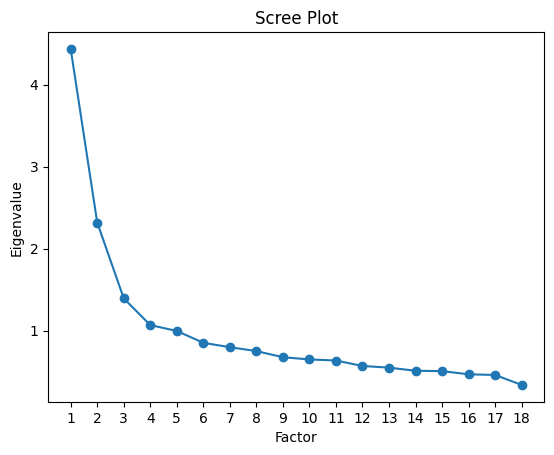

    Factor  Eigenvalue
0        1    4.434974
1        2    2.318979
2        3    1.394768
3        4    1.069456
4        5    0.997734
5        6    0.853363
6        7    0.799706
7        8    0.752306
8        9    0.677626
9       10    0.650590
10      11    0.637368
11      12    0.570994
12      13    0.550745
13      14    0.512439
14      15    0.507953
15      16    0.469631
16      17    0.461371
17      18    0.339998


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from factor_analyzer import FactorAnalyzer

# Calculate eigenvalues using FactorAnalyzer
fa_eigen = FactorAnalyzer(rotation=None)
fa_eigen.fit(X_scaled)
ev, v = fa_eigen.get_eigenvalues()
eigenvalues = ev # 'ev' contains the eigenvalues needed for the scree plot

plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.xticks(range(1, len(eigenvalues)+1))  # force integer labels

plt.title("Scree Plot")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.show()

eigen_df = pd.DataFrame({
    "Factor": range(1, len(eigenvalues)+1),
    "Eigenvalue": eigenvalues
})

print(eigen_df)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
pca.fit(X_scaled)

PCA(n_components=4)

**VARIMAX**

In [10]:
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=4, rotation='varimax', rotation_kwargs={})

In [11]:
import pandas as pd

loadings = pd.DataFrame(
    fa.loadings_,
    index=X_scaled.columns,
    columns=["Factor1", "Factor2", "Factor3", "Factor4"]
)

print(loadings)

                         Factor1   Factor2   Factor3   Factor4
peer_competition        0.183339  0.153475  0.031628  0.260768
lecturer_strictness     0.196368  0.158100 -0.000626  0.643675
lecturer_expectations   0.169229  0.096464 -0.144926  0.624204
parental_expectations   0.208253  0.326429  0.200339  0.335259
time_management         0.206921  0.042161  0.442909 -0.183296
curriculum_load         0.533196  0.187677  0.002661  0.175719
assignment_load         0.606369  0.199022  0.072451  0.198609
difficulty_catching_up  0.468033  0.295222  0.080961  0.236027
relaxation_time         0.228188  0.011655  0.234660 -0.261782
exam_difficulty         0.503719  0.384445  0.015707  0.118453
exam_time_pressure      0.466970  0.412383  0.027375  0.104267
exam_stress             0.469033  0.458225  0.020274  0.021212
academic_confidence    -0.040101  0.020904  0.752109  0.030665
career_confidence      -0.080697 -0.012643  0.804239  0.074950
decision_making         0.056740  0.115348  0.521186 -0

In [12]:
loadings_filtered = loadings.where(abs(loadings) >= 0.4)
print(loadings_filtered)

                         Factor1   Factor2   Factor3   Factor4
peer_competition             NaN       NaN       NaN       NaN
lecturer_strictness          NaN       NaN       NaN  0.643675
lecturer_expectations        NaN       NaN       NaN  0.624204
parental_expectations        NaN       NaN       NaN       NaN
time_management              NaN       NaN  0.442909       NaN
curriculum_load         0.533196       NaN       NaN       NaN
assignment_load         0.606369       NaN       NaN       NaN
difficulty_catching_up  0.468033       NaN       NaN       NaN
relaxation_time              NaN       NaN       NaN       NaN
exam_difficulty         0.503719       NaN       NaN       NaN
exam_time_pressure      0.466970  0.412383       NaN       NaN
exam_stress             0.469033  0.458225       NaN       NaN
academic_confidence          NaN       NaN  0.752109       NaN
career_confidence            NaN       NaN  0.804239       NaN
decision_making              NaN       NaN  0.521186   

In [13]:
!pip install pingouin

import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.9 MB/s eta 0:00:00


In [14]:
factors = {
    "F1": ['curriculum_load','assignment_load','difficulty_catching_up',
           'exam_difficulty','exam_time_pressure','exam_stress'],

    "F2": ['module_failure','exam_concern','employment_concern'],

    "F3": ['academic_confidence','career_confidence',
           'decision_making','time_management'],

    "F4": ['lecturer_strictness','lecturer_expectations']
}

In [15]:
for name, cols in factors.items():
    alpha, _ = pg.cronbach_alpha(data=df[cols])
    print(f"{name} Alpha:", round(alpha, 3))

F1 Alpha: 0.791
F2 Alpha: 0.652
F3 Alpha: 0.708
F4 Alpha: 0.662


In [16]:
df['F1'] = df[factors['F1']].mean(axis=1)
df['F2'] = df[factors['F2']].mean(axis=1)
df['F3'] = df[factors['F3']].mean(axis=1)
df['F4'] = df[factors['F4']].mean(axis=1)

In [17]:
df.head()

,gender,marital_status,academic_failure,faculty_environment,home_environment,age_group,academic_year,degree_program,peer_competition,lecturer_strictness,...,academic_confidence,career_confidence,decision_making,module_failure,exam_concern,employment_concern,F1,F2,F3,F4
0,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,2.0,2.0,4.0,4.0,4.0,4.0,3.333333,4.000000,3.00,2.5
1,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in International Business,3.0,2.0,...,2.0,2.0,4.0,4.0,3.0,4.0,3.000000,3.666667,2.75,2.0
2,Female,Single,Never,Very satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Human Resource Management,2.0,2.0,...,2.0,3.0,2.0,2.0,1.0,3.0,3.500000,2.000000,2.00,2.0
3,Male,Single,Once or twice,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,2.0,3.0,4.0,2.0,3.0,3.000000,3.000000,2.50,3.0
4,Male,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,5.0,4.0,...,1.0,2.0,1.0,4.0,4.0,5.0,3.833333,4.333333,1.50,4.0


In [18]:
cols = [
    'F1','F2','F3','F4',
    'gender','marital_status','academic_year','academic_failure','age_group',
    'degree_program','faculty_environment','home_environment'
]

df = df[cols]

In [19]:
df.to_csv('Clustering_ready_dataset.csv', index=False)
from google.colab import files
files.download('Clustering_ready_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>